# 04. PyTorch Stage-wise Gradient Boosting Baseline

저장된 02 가격 feature와 03의 `TP +5% / SL -3% / 10분` dual-path 라벨을 결합해 baseline을 학습한다.

이 notebook의 모델은 GBDT 라이브러리가 아니라 PyTorch 기반의 stage-wise additive classifier다. 각 stage에서 얕은 신경망 weak learner를 이전 logit에 더해 binary cross-entropy를 줄인다.

비교 대상:

1. 직접 성공 확률 `P(TP first within 10m)`
2. 두 단계 확률 `P(fill) × P(TP first within 10m | fill)`

입력에는 OHLC와 timestamp에서 계산된 가격·시간 feature만 사용하며 volume, VWAP, quote, trade-flow는 사용하지 않는다.

In [1]:
from __future__ import annotations

import json
import math
import random
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
)
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert "envs/urban" in str(Path(sys.executable).resolve()), f"urban 환경이 아닙니다: {sys.executable}"
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"device: {DEVICE}")


python: /home/user/anaconda3/envs/urban/bin/python
torch: 2.9.1+cu128
device: cuda


## 1. 저장 artifact 확인

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENT.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = (PROJECT_ROOT / "../../data/stock_data").resolve()
PROCESSED_ROOT = DATA_ROOT / "processed"
MODEL_ROOT = DATA_ROOT / "models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

FEATURE_ROWS_PATH = PROCESSED_ROOT / "feature_rows_price_v2.parquet"
SEQUENCE_INDEX_PATH = PROCESSED_ROOT / "sequence_index_price_v2.parquet"
LABELS_PATH = PROCESSED_ROOT / "labels_dual_path_10m_tp5_sl3_v2.parquet"
TABULAR_PATH = PROCESSED_ROOT / "baseline_tabular_10m_tp5_sl3_price_v2.parquet"
FEATURE_SCHEMA_PATH = PROCESSED_ROOT / "baseline_tabular_10m_tp5_sl3_price_v2_schema.json"
SCALER_PATH = PROCESSED_ROOT / "baseline_tabular_10m_tp5_sl3_price_v2_scaler.parquet"
PREDICTIONS_PATH = PROCESSED_ROOT / "baseline_torch_predictions_10m_tp5_sl3_price_v2.parquet"
HISTORY_PATH = PROCESSED_ROOT / "baseline_torch_stage_history_10m_tp5_sl3_price_v2.parquet"
METRICS_PATH = PROCESSED_ROOT / "baseline_torch_metrics_10m_tp5_sl3_price_v2.parquet"
TOP_SIGNAL_PATH = PROCESSED_ROOT / "baseline_torch_top_signal_metrics_10m_tp5_sl3_price_v2.parquet"
THRESHOLD_PATH = PROCESSED_ROOT / "baseline_torch_threshold_metrics_10m_tp5_sl3_price_v2.parquet"
MANIFEST_PATH = MODEL_ROOT / "torch_stagewise_boosting_10m_tp5_sl3_price_v2_manifest.json"

required_artifacts = [FEATURE_ROWS_PATH, SEQUENCE_INDEX_PATH, LABELS_PATH]
missing = [str(path) for path in required_artifacts if not path.exists()]
assert not missing, f"02·03 저장 artifact가 없습니다: {missing}"
display(pd.DataFrame({
    "path": [str(path) for path in required_artifacts],
    "size_mb": [path.stat().st_size / 1024**2 for path in required_artifacts],
}))


,path,size_mb
0,/home/user/urbandatalab/YSLee/data/stock_data/...,23.798107
1,/home/user/urbandatalab/YSLee/data/stock_data/...,0.214855
2,/home/user/urbandatalab/YSLee/data/stock_data/...,1.897562


## 2. 60봉 tabular 집계 및 라벨 결합

각 60봉 sequence를 `last`, `mean60`, `std60`, `delta5`, `delta20`으로 집계한다. 기술지표 자체가 다양한 lookback을 포함하므로 baseline 차원을 과도하게 늘리지 않는다.

In [3]:
FEATURE_METADATA = ["source_path", "session", "split", "symbol", "run_id", "feature_row", "timestamp_utc"]
MERGE_KEYS = ["source_path", "symbol", "input_end_timestamp"]

feature_rows = pd.read_parquet(FEATURE_ROWS_PATH)
sequence_index = pd.read_parquet(SEQUENCE_INDEX_PATH)
labels = pd.read_parquet(LABELS_PATH)
model_features = [column for column in feature_rows.columns if column not in FEATURE_METADATA]

label_columns = [
    *MERGE_KEYS, "session", "split", "label_version",
    "reference_close", "tick_size", "entry_price", "fill_threshold",
    "take_profit_price", "stop_loss_price", "shares",
    "dual_agreement_10m", "dual_outcome_10m",
    "target_entry_fill", "binary_target_10m",
    "binary_target_tp_given_fill_10m", "expected_net_return_dual_10m",
]
label_view = labels[label_columns].rename(columns={"session": "label_session", "split": "label_split"})
dataset_index = sequence_index.merge(label_view, on=MERGE_KEYS, how="inner", validate="one_to_one")
assert len(dataset_index) == len(labels)
assert dataset_index["split"].eq(dataset_index["label_split"]).all()
assert dataset_index["session"].eq(dataset_index["label_session"]).all()
assert set(dataset_index["label_version"]) == {"dual_path_10m_tp5_sl3_v2"}

aggregate_names = []
for prefix in ["last", "mean60", "std60", "delta5", "delta20"]:
    aggregate_names.extend([f"{prefix}__{feature}" for feature in model_features])

X_aggregated = np.empty((len(dataset_index), len(aggregate_names)), dtype=np.float32)
for source_path, positions_index in dataset_index.groupby("source_path", sort=False).groups.items():
    positions = np.asarray(list(positions_index), dtype=np.int64)
    metadata = dataset_index.loc[positions]
    rows = feature_rows.loc[feature_rows["source_path"].eq(source_path)].sort_values("feature_row")
    row_numbers = rows["feature_row"].to_numpy(dtype=np.int64)
    assert np.array_equal(row_numbers, np.arange(len(rows), dtype=np.int64))
    matrix = rows[model_features].to_numpy(dtype=np.float32)
    safe_matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
    prefix = np.vstack([np.zeros((1, len(model_features))), np.cumsum(safe_matrix, axis=0)])
    prefix_sq = np.vstack([np.zeros((1, len(model_features))), np.cumsum(safe_matrix**2, axis=0)])
    start = metadata["start_feature_row"].to_numpy(dtype=np.int64)
    end = metadata["end_feature_row"].to_numpy(dtype=np.int64)
    assert np.all(end - start + 1 == 60)
    last = matrix[end]
    mean60 = (prefix[end + 1] - prefix[start]) / 60.0
    second_moment = (prefix_sq[end + 1] - prefix_sq[start]) / 60.0
    std60 = np.sqrt(np.maximum(second_moment - mean60**2, 0.0))
    delta5 = last - matrix[end - 5]
    delta20 = last - matrix[end - 20]
    block = np.concatenate([last, mean60, std60, delta5, delta20], axis=1).astype(np.float32)
    assert np.isfinite(block).all()
    X_aggregated[positions] = block

assert len(model_features) == 90
assert X_aggregated.shape == (len(dataset_index), 5 * len(model_features))
assert not any(any(token in name.lower() for token in ["volume", "vwap", "notional", "quote", "bid", "ask", "trade_count"]) for name in aggregate_names)

tabular_features = pd.DataFrame(X_aggregated, columns=aggregate_names)
baseline_df = pd.concat([dataset_index.reset_index(drop=True), tabular_features], axis=1)
baseline_df.to_parquet(TABULAR_PATH, index=False, compression="zstd")
FEATURE_SCHEMA_PATH.write_text(json.dumps({
    "feature_version": "price_v2_no_weekday_tabular_60bar_v1",
    "base_feature_count": len(model_features),
    "tabular_feature_count": len(aggregate_names),
    "aggregation": ["last", "mean60", "std60", "delta5", "delta20"],
    "features": aggregate_names,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"saved: {TABULAR_PATH} ({len(baseline_df):,} rows, {len(aggregate_names)} features)")


saved: /home/user/urbandatalab/YSLee/data/stock_data/processed/baseline_tabular_10m_tp5_sl3_price_v2.parquet (49,084 rows, 450 features)


In [4]:
split_summary = baseline_df.groupby("split").agg(
    samples=("symbol", "size"),
    symbols=("symbol", "nunique"),
    sessions=("session", "nunique"),
    start=("input_end_timestamp", "min"),
    end=("input_end_timestamp", "max"),
    fill_rate=("target_entry_fill", "mean"),
    direct_positive_rate=("binary_target_10m", "mean"),
).reindex(["train", "validation", "test"])
display(split_summary)
assert split_summary.loc["train", "end"] < split_summary.loc["validation", "start"]
assert split_summary.loc["validation", "end"] < split_summary.loc["test", "start"]


,samples,symbols,sessions,start,end,fill_rate,direct_positive_rate
split,,,,,,,
train,23261,53,4,2026-07-07 09:59:00+00:00,2026-07-10 22:50:00+00:00,0.394351,0.053388
validation,10627,26,2,2026-07-13 09:59:00+00:00,2026-07-14 22:50:00+00:00,0.470876,0.057232
test,15196,36,3,2026-07-15 09:59:00+00:00,2026-07-17 22:50:00+00:00,0.423862,0.045257


## 3. Train-only robust scaling

median과 IQR은 train split에서만 계산한다. validation과 test는 train 통계로만 변환한다.

In [5]:
X_raw = baseline_df[aggregate_names].to_numpy(dtype=np.float32)
train_mask_all = baseline_df["split"].eq("train").to_numpy()
train_raw = X_raw[train_mask_all].astype(np.float64)
scaler_center = np.median(train_raw, axis=0)
q25 = np.quantile(train_raw, 0.25, axis=0)
q75 = np.quantile(train_raw, 0.75, axis=0)
scaler_scale = q75 - q25
scaler_scale = np.where(scaler_scale > 1e-8, scaler_scale, 1.0)
X_scaled = np.clip((X_raw - scaler_center) / scaler_scale, -20.0, 20.0).astype(np.float32)
assert np.isfinite(X_scaled).all()

scaler_df = pd.DataFrame({
    "feature": aggregate_names,
    "train_median": scaler_center,
    "train_iqr": scaler_scale,
})
scaler_df.to_parquet(SCALER_PATH, index=False, compression="zstd")
display(scaler_df.sort_values("train_iqr").head(10))


,feature,train_median,train_iqr
316,delta5__rolling_std_return_60,-0.000036,0.000477
91,mean60__open_rel_prev_close,0.000003,0.000480
106,mean60__gap_from_prev_close,0.000003,0.000480
145,mean60__macd_hist_scaled,0.000023,0.000911
118,mean60__close_to_ema3,-0.000085,0.001036
112,mean60__close_to_sma3,-0.000071,0.001045
94,mean60__close_rel_prev_close,-0.000042,0.001045
95,mean60__log_return_1,-0.000072,0.001054
101,mean60__body_return,-0.000070,0.001188
315,delta5__rolling_std_return_20,-0.000039,0.001347


## 4. PyTorch stage-wise additive classifier

각 weak learner는 `Linear → ReLU → Linear` 구조다. 기존 ensemble의 logit은 고정하고 새 learner만 학습한 뒤 shrinkage를 적용해 추가한다. class weight는 사용하지 않아 출력 확률의 calibration을 유지한다.

In [6]:
class WeakLearner(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        nn.init.zeros_(self.network[-1].weight)
        nn.init.zeros_(self.network[-1].bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


class TorchStagewiseBoostingClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, shrinkage: float, initial_bias: float):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.shrinkage = shrinkage
        self.register_buffer("initial_bias", torch.tensor(float(initial_bias), dtype=torch.float32))
        self.learners = nn.ModuleList()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.initial_bias.expand(x.shape[0])
        for learner in self.learners:
            logits = logits + self.shrinkage * learner(x)
        return logits


def predict_logits(model: nn.Module, X: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[start:start + batch_size]).to(DEVICE)
            outputs.append(model(batch).detach().cpu().numpy())
    return np.concatenate(outputs).astype(np.float32)


BOOSTING_CONFIG = {
    "hidden_dim": 32,
    "shrinkage": 0.5,
    "max_stages": 6,
    "max_epochs_per_stage": 10,
    "patience": 3,
    "batch_size": 1024,
    "learning_rate": 0.002,
    "weight_decay": 1e-5,
    "min_delta": 1e-5,
}
display(pd.Series(BOOSTING_CONFIG, name="value").to_frame())


,value
hidden_dim,32.00000
shrinkage,0.50000
max_stages,6.00000
max_epochs_per_stage,10.00000
patience,3.00000
batch_size,1024.00000
learning_rate,0.00200
weight_decay,0.00001
min_delta,0.00001


In [7]:
def fit_stagewise_model(X: np.ndarray, y: np.ndarray, split: np.ndarray, model_name: str, seed_offset: int = 0):
    cfg = BOOSTING_CONFIG
    train_idx = np.flatnonzero(split == "train")
    validation_idx = np.flatnonzero(split == "validation")
    assert len(np.unique(y[train_idx])) == 2
    positive_rate = float(y[train_idx].mean())
    initial_bias = math.log(positive_rate / (1.0 - positive_rate))
    model = TorchStagewiseBoostingClassifier(
        input_dim=X.shape[1],
        hidden_dim=cfg["hidden_dim"],
        shrinkage=cfg["shrinkage"],
        initial_bias=initial_bias,
    ).to(DEVICE)

    X_train = X[train_idx]
    y_train = y[train_idx].astype(np.float32)
    X_validation = X[validation_idx]
    y_validation = y[validation_idx].astype(np.float32)
    current_validation_loss = float(F.binary_cross_entropy_with_logits(
        torch.full((len(y_validation),), initial_bias),
        torch.from_numpy(y_validation),
    ))
    history = []

    for stage in range(1, cfg["max_stages"] + 1):
        base_train = predict_logits(model, X_train)
        base_validation = predict_logits(model, X_validation)
        train_dataset = TensorDataset(
            torch.from_numpy(X_train),
            torch.from_numpy(y_train),
            torch.from_numpy(base_train),
        )
        generator = torch.Generator().manual_seed(SEED + seed_offset + stage)
        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg["batch_size"],
            shuffle=True,
            generator=generator,
            pin_memory=DEVICE.type == "cuda",
        )
        weak = WeakLearner(X.shape[1], cfg["hidden_dim"]).to(DEVICE)
        optimizer = torch.optim.AdamW(
            weak.parameters(),
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
        )
        best_state = deepcopy(weak.state_dict())
        best_stage_validation_loss = current_validation_loss
        epochs_without_improvement = 0

        for epoch in range(1, cfg["max_epochs_per_stage"] + 1):
            weak.train()
            for X_batch, y_batch, base_batch in train_loader:
                X_batch = X_batch.to(DEVICE, non_blocking=True)
                y_batch = y_batch.to(DEVICE, non_blocking=True)
                base_batch = base_batch.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                logits = base_batch + cfg["shrinkage"] * weak(X_batch)
                loss = F.binary_cross_entropy_with_logits(logits, y_batch)
                loss.backward()
                optimizer.step()

            weak.eval()
            with torch.no_grad():
                validation_delta = predict_logits(weak, X_validation)
                validation_logits = base_validation + cfg["shrinkage"] * validation_delta
                validation_loss = float(F.binary_cross_entropy_with_logits(
                    torch.from_numpy(validation_logits),
                    torch.from_numpy(y_validation),
                ))
            if validation_loss < best_stage_validation_loss - cfg["min_delta"]:
                best_stage_validation_loss = validation_loss
                best_state = deepcopy(weak.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= cfg["patience"]:
                    break

        if best_stage_validation_loss >= current_validation_loss - cfg["min_delta"]:
            break
        weak.load_state_dict(best_state)
        model.learners.append(weak)
        current_validation_loss = best_stage_validation_loss
        history.append({
            "model": model_name,
            "stage": stage,
            "validation_logloss": current_validation_loss,
            "epochs": epoch,
        })
        print(f"{model_name}: stage={stage}, val_logloss={current_validation_loss:.6f}, epochs={epoch}")

    assert len(model.learners) >= 1, f"{model_name}: 학습된 weak learner가 없습니다."
    return model, pd.DataFrame(history)


## 5. Direct 및 two-stage 모델 학습

In [8]:
split_all = baseline_df["split"].to_numpy(dtype=str)
target_specs = {
    "direct": (baseline_df["binary_target_10m"].notna().to_numpy(), "binary_target_10m"),
    "fill": (np.ones(len(baseline_df), dtype=bool), "target_entry_fill"),
    "tp_given_fill": (baseline_df["binary_target_tp_given_fill_10m"].notna().to_numpy(), "binary_target_tp_given_fill_10m"),
}

models = {}
probabilities = {}
history_frames = []
target_audit_rows = []
for seed_offset, (name, (mask, target_column)) in enumerate(target_specs.items(), start=1):
    y = baseline_df.loc[mask, target_column].to_numpy(dtype=np.float32)
    split = split_all[mask]
    target_audit_rows.append({
        "model": name,
        "samples": len(y),
        "train_samples": int((split == "train").sum()),
        "train_positive_rate": float(y[split == "train"].mean()),
        "validation_positive_rate": float(y[split == "validation"].mean()),
        "test_positive_rate": float(y[split == "test"].mean()),
    })
    model, history = fit_stagewise_model(X_scaled[mask], y, split, name, seed_offset * 100)
    probabilities[name] = torch.sigmoid(torch.from_numpy(predict_logits(model, X_scaled))).numpy()
    models[name] = model.cpu()
    history_frames.append(history)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

class TorchReturnRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(128, 32), nn.ReLU(), nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)

def predict_returns(model: nn.Module, X: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[start:start + batch_size]).to(DEVICE)
            outputs.append(model(batch).detach().cpu().numpy())
    return np.concatenate(outputs).astype(np.float32) / 100.0

RETURN_CONFIG = {'hidden_dims': [128, 32], 'dropout': 0.15, 'target_scale': 100.0, 'huber_beta': 0.5, 'max_epochs': 60, 'patience': 8, 'batch_size': 1024, 'learning_rate': 0.0005, 'weight_decay': 0.0003}
return_model = TorchReturnRegressor(X_scaled.shape[1]).to(DEVICE)
return_target = baseline_df['expected_net_return_dual_10m'].to_numpy(dtype=np.float32) * RETURN_CONFIG['target_scale']
return_train = split_all == 'train'
return_validation = split_all == 'validation'
return_dataset = TensorDataset(torch.from_numpy(X_scaled[return_train]), torch.from_numpy(return_target[return_train]))
return_loader = DataLoader(return_dataset, batch_size=RETURN_CONFIG['batch_size'], shuffle=True, generator=torch.Generator().manual_seed(SEED + 900), pin_memory=DEVICE.type == 'cuda')
return_optimizer = torch.optim.AdamW(return_model.parameters(), lr=RETURN_CONFIG['learning_rate'], weight_decay=RETURN_CONFIG['weight_decay'])
best_return_loss = np.inf
best_return_state = deepcopy(return_model.state_dict())
return_epochs_without_improvement = 0
return_history_rows = []
for epoch in range(1, RETURN_CONFIG['max_epochs'] + 1):
    return_model.train()
    for X_batch, y_batch in return_loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        return_optimizer.zero_grad(set_to_none=True)
        loss = F.smooth_l1_loss(return_model(X_batch), y_batch, beta=RETURN_CONFIG['huber_beta'])
        loss.backward()
        return_optimizer.step()
    validation_prediction_scaled = predict_returns(return_model, X_scaled[return_validation]) * RETURN_CONFIG['target_scale']
    validation_loss = float(F.smooth_l1_loss(torch.from_numpy(validation_prediction_scaled), torch.from_numpy(return_target[return_validation]), beta=RETURN_CONFIG['huber_beta']))
    if validation_loss < best_return_loss - 1e-5:
        best_return_loss = validation_loss
        best_return_state = deepcopy(return_model.state_dict())
        return_epochs_without_improvement = 0
    else:
        return_epochs_without_improvement += 1
    return_history_rows.append({'model': 'expected_return', 'epoch': epoch, 'validation_huber': validation_loss})
    if return_epochs_without_improvement >= RETURN_CONFIG['patience']:
        break
return_model.load_state_dict(best_return_state)
probabilities["two_stage"] = probabilities["fill"] * probabilities["tp_given_fill"]
probabilities["expected_return"] = predict_returns(return_model, X_scaled)
history_frames.append(pd.DataFrame(return_history_rows))
target_audit_rows.append({'model': 'expected_return', 'samples': len(return_target), 'train_samples': int(return_train.sum()), 'train_positive_rate': float((return_target[return_train] > 0).mean()), 'validation_positive_rate': float((return_target[return_validation] > 0).mean()), 'test_positive_rate': float((return_target[split_all == 'test'] > 0).mean())})
target_audit_df = pd.DataFrame(target_audit_rows).set_index("model")
history_df = pd.concat(history_frames, ignore_index=True)
display(target_audit_df)
display(history_df)


direct: stage=1, val_logloss=0.185262, epochs=8


direct: stage=2, val_logloss=0.185251, epochs=4


direct: stage=3, val_logloss=0.185171, epochs=4


direct: stage=4, val_logloss=0.185064, epochs=6


fill: stage=1, val_logloss=0.564262, epochs=10


tp_given_fill: stage=1, val_logloss=0.342825, epochs=10


tp_given_fill: stage=2, val_logloss=0.339908, epochs=9


,samples,train_samples,train_positive_rate,validation_positive_rate,test_positive_rate
model,,,,,
direct,49012,23226,0.053388,0.057232,0.045257
fill,49084,23261,0.394351,0.470876,0.423862
tp_given_fill,20546,9138,0.135697,0.121814,0.106926
expected_return,49084,23261,0.129272,0.154700,0.144841


,model,stage,validation_logloss,epochs,epoch,validation_huber
0,direct,1.0,0.185262,8.0,NaN,NaN
1,direct,2.0,0.185251,4.0,NaN,NaN
2,direct,3.0,0.185171,4.0,NaN,NaN
3,direct,4.0,0.185064,6.0,NaN,NaN
4,fill,1.0,0.564262,10.0,NaN,NaN
5,tp_given_fill,1.0,0.342825,10.0,NaN,NaN
6,tp_given_fill,2.0,0.339908,9.0,NaN,NaN
7,expected_return,NaN,NaN,NaN,1.0,0.938515
8,expected_return,NaN,NaN,NaN,2.0,0.936915
9,expected_return,NaN,NaN,NaN,3.0,0.935853


## 6. 확률·상위 신호·경제성 평가

라벨 불균형이 크므로 ROC-AUC와 함께 PR-AUC, Brier score, 상위 1·3·5% precision을 본다. 분류 점수와 별도로 실제 수수료 차감 순수익률을 Huber loss로 학습한 `expected_return` 점수를 비교한다. 경제성은 05 순차 백테스트 전의 proxy이며 중복 포지션을 고려하지 않는다.

In [9]:
direct_mask = baseline_df["binary_target_10m"].notna().to_numpy()
y_direct = baseline_df.loc[direct_mask, "binary_target_10m"].to_numpy(dtype=np.float32)
split_direct = split_all[direct_mask]
net_return_direct = baseline_df.loc[direct_mask, "expected_net_return_dual_10m"].to_numpy(dtype=np.float32)

metric_rows = []
top_rows = []
for score_name in ["direct", "two_stage", "expected_return"]:
    score = probabilities[score_name][direct_mask]
    for split_name in ["train", "validation", "test"]:
        mask = split_direct == split_name
        y_split = y_direct[mask]
        score_split = score[mask]
        return_split = net_return_direct[mask]
        metric_rows.append({
            "score": score_name,
            "split": split_name,
            "samples": len(y_split),
            "positive_rate": float(y_split.mean()),
            "roc_auc": roc_auc_score(y_split, score_split),
            "pr_auc": average_precision_score(y_split, score_split),
            "brier": brier_score_loss(y_split, score_split) if score_name != "expected_return" else np.nan,
            "return_spearman": pd.Series(return_split).corr(pd.Series(score_split), method='spearman'),
            "return_mae": float(np.mean(np.abs(return_split - score_split))) if score_name == "expected_return" else np.nan,
        })
        order = np.argsort(-score_split)
        for top_share in [0.01, 0.03, 0.05]:
            count = max(1, int(math.ceil(len(order) * top_share)))
            selected = order[:count]
            top_rows.append({
                "score": score_name,
                "split": split_name,
                "top_share": top_share,
                "signals": count,
                "precision": float(y_split[selected].mean()),
                "mean_net_return_proxy": float(return_split[selected].mean()),
                "sum_net_return_proxy": float(return_split[selected].sum()),
            })

metrics_df = pd.DataFrame(metric_rows)
top_signal_df = pd.DataFrame(top_rows)
display(metrics_df.set_index(["score", "split"]))
display(top_signal_df.query("split in ['validation', 'test']").set_index(["score", "split", "top_share"]))


samples  positive_rate   roc_auc    pr_auc  \
score           split                                                    
direct          train         23226       0.053388  0.839721  0.228726   
                validation    10606       0.057232  0.806943  0.180253   
                test          15180       0.045257  0.797143  0.141818   
two_stage       train         23226       0.053388  0.847132  0.253404   
                validation    10606       0.057232  0.805541  0.176691   
                test          15180       0.045257  0.807750  0.143528   
expected_return train         23226       0.053388  0.477804  0.132074   
                validation    10606       0.057232  0.311416  0.052633   
                test          15180       0.045257  0.304217  0.038111   

                               brier  return_spearman  return_mae  
score           split                                              
direct          train       0.045420        -0.119151         NaN  
                validation  0.050198        -0.141996         NaN  
                test        0.040980        -0.123989         NaN  
two_stage       train       0.044746        -0.133729         NaN  
                validation  0.050262        -0.153370         NaN  
                test        0.040870        -0.140402         NaN  
expected_return train            NaN         0.349364    0.009029  
                validation       NaN         0.158265    0.010828  
                test             NaN         0.155279    0.009435

signals  precision  \
score           split      top_share                       
direct          validation 0.01           107   0.242991   
                           0.03           319   0.216301   
                           0.05           531   0.212806   
                test       0.01           152   0.250000   
                           0.03           456   0.195175   
                           0.05           759   0.177866   
two_stage       validation 0.01           107   0.224299   
                           0.03           319   0.216301   
                           0.05           531   0.203390   
                test       0.01           152   0.217105   
                           0.03           456   0.192982   
                           0.05           759   0.183136   
expected_return validation 0.01           107   0.149533   
                           0.03           319   0.100313   
                           0.05           531   0.082863   
                test       0.01           152   0.085526   
                           0.03           456   0.087719   
                           0.05           759   0.071146   

                                      mean_net_return_proxy  \
score           split      top_share                          
direct          validation 0.01                   -0.009210   
                           0.03                   -0.009008   
                           0.05                   -0.007513   
                test       0.01                   -0.005064   
                           0.03                   -0.007359   
                           0.05                   -0.006542   
two_stage       validation 0.01                   -0.009785   
                           0.03                   -0.008444   
                           0.05                   -0.007839   
                test       0.01                   -0.007931   
                           0.03                   -0.007763   
                           0.05                   -0.006767   
expected_return validation 0.01                   -0.003190   
                           0.03                   -0.002620   
                           0.05                   -0.002833   
                test       0.01                   -0.004408   
                           0.03                   -0.002029   
                           0.05                   -0.002049   

                                      sum_net_return_proxy  
score           split      top_share                        
direct          validation 0.01                  -0.985476  
                           0.03                  -2.873651  
                           0.05                  -3.989139  
                test       0.01                  -0.769764  
                           0.03                  -3.355573  
                           0.05                  -4.965004  
two_stage       validation 0.01                  -1.046998  
                           0.03                  -2.693791  
                           0.05                  -4.162320  
                test       0.01                  -1.205558  
                           0.03                  -3.540076  
                           0.05                  -5.136097  
expected_return validation 0.01                  -0.341296  
                           0.03                  -0.835685  
                           0.05                  -1.504318  
                test       0.01                  -0.670050  
                           0.03                  -0.925044  
                           0.05                  -1.555130

validation_top5_threshold  signals  precision  \
score           split                                                       
direct          validation                   0.183664      531   0.212806   
                test                         0.183664      404   0.205446   
two_stage       validation                   0.190692      531   0.203390   
                test                         0.190692      407   0.206388   
expected_return validation                   0.000965      531   0.082863   
                test                         0.000965      845   0.068639   

                            mean_net_return_proxy  
score           split                              
direct          validation              -0.007513  
                test                    -0.006931  
two_stage       validation              -0.007839  
                test                    -0.007237  
expected_return validation              -0.002833  
                test                    -0.001946

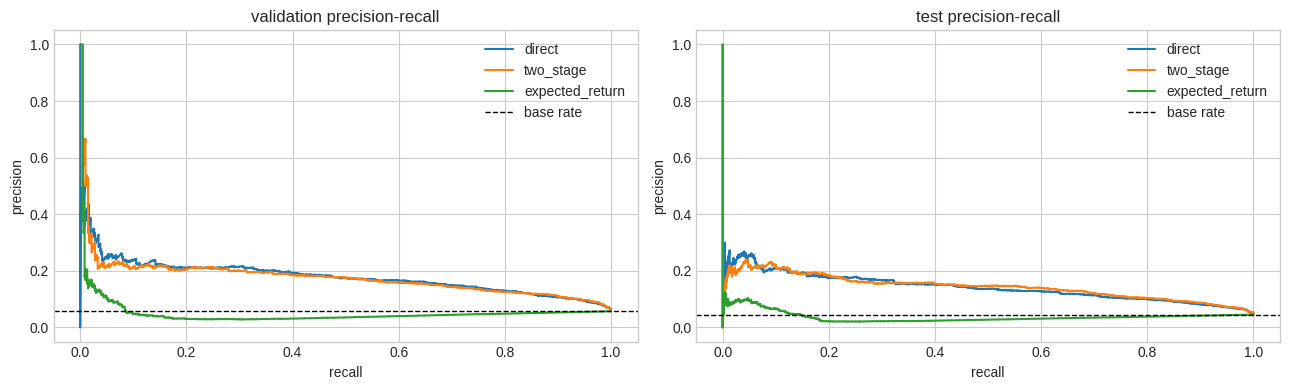

In [10]:
threshold_rows = []
for score_name in ["direct", "two_stage", "expected_return"]:
    score = probabilities[score_name][direct_mask]
    validation_scores = score[split_direct == "validation"]
    threshold = float(np.quantile(validation_scores, 0.95))
    for split_name in ["validation", "test"]:
        split_mask = split_direct == split_name
        selected = split_mask & (score >= threshold)
        threshold_rows.append({
            "score": score_name,
            "split": split_name,
            "validation_top5_threshold": threshold,
            "signals": int(selected.sum()),
            "precision": float(y_direct[selected].mean()) if selected.any() else np.nan,
            "mean_net_return_proxy": float(net_return_direct[selected].mean()) if selected.any() else np.nan,
        })
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.set_index(["score", "split"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, split_name in zip(axes, ["validation", "test"]):
    split_mask = split_direct == split_name
    for score_name in ["direct", "two_stage", "expected_return"]:
        precision, recall, _ = precision_recall_curve(y_direct[split_mask], probabilities[score_name][direct_mask][split_mask])
        axis.plot(recall, precision, label=score_name)
    axis.axhline(y_direct[split_mask].mean(), color="black", linestyle="--", linewidth=1, label="base rate")
    axis.set_title(f"{split_name} precision-recall")
    axis.set_xlabel("recall")
    axis.set_ylabel("precision")
    axis.legend()
plt.tight_layout()
plt.show()


## 7. 모델·예측·manifest 저장 및 검증

In [11]:
checkpoint_paths = {}
for name, model in models.items():
    checkpoint_path = MODEL_ROOT / f"torch_stagewise_{name}_10m_tp5_sl3_price_v2.pt"
    torch.save({
        "model_name": name,
        "model_state_dict": model.state_dict(),
        "input_dim": len(aggregate_names),
        "hidden_dim": BOOSTING_CONFIG["hidden_dim"],
        "shrinkage": BOOSTING_CONFIG["shrinkage"],
        "n_stages": len(model.learners),
        "feature_names": aggregate_names,
        "scaler_center": torch.from_numpy(scaler_center),
        "scaler_scale": torch.from_numpy(scaler_scale),
        "label_version": "dual_path_10m_tp5_sl3_v2",
        "seed": SEED,
    }, checkpoint_path)
    checkpoint_paths[name] = str(checkpoint_path)
return_checkpoint_path = MODEL_ROOT / "torch_expected_return_10m_tp5_sl3_price_v2.pt"
torch.save({
    'model_name': 'expected_return', 'model_state_dict': return_model.cpu().state_dict(),
    'input_dim': len(aggregate_names), 'feature_names': aggregate_names,
    'scaler_center': torch.from_numpy(scaler_center), 'scaler_scale': torch.from_numpy(scaler_scale),
    'label_version': 'dual_path_10m_tp5_sl3_v2', 'return_config': RETURN_CONFIG, 'seed': SEED,
}, return_checkpoint_path)
checkpoint_paths['expected_return'] = str(return_checkpoint_path)

prediction_columns = [
    "source_path", "session", "split", "symbol", "input_end_timestamp",
    "dual_outcome_10m", "binary_target_10m", "target_entry_fill",
    "binary_target_tp_given_fill_10m", "expected_net_return_dual_10m",
]
predictions_df = baseline_df[prediction_columns].copy()
for name in ['direct', 'fill', 'tp_given_fill', 'two_stage']:
    predictions_df[f"probability_{name}"] = probabilities[name].astype(np.float32)
predictions_df['predicted_expected_net_return'] = probabilities['expected_return'].astype(np.float32)
predictions_df.to_parquet(PREDICTIONS_PATH, index=False, compression="zstd")
history_df.to_parquet(HISTORY_PATH, index=False, compression="zstd")
metrics_df.to_parquet(METRICS_PATH, index=False, compression="zstd")
top_signal_df.to_parquet(TOP_SIGNAL_PATH, index=False, compression="zstd")
threshold_df.to_parquet(THRESHOLD_PATH, index=False, compression="zstd")

manifest = {
    "environment": "urban",
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "device_used": str(DEVICE),
    "seed": SEED,
    "label_version": "dual_path_10m_tp5_sl3_v2",
    "horizon_minutes": 10,
    "take_profit_pct": 0.05,
    "stop_loss_pct": 0.03,
    "tabular_dataset": str(TABULAR_PATH),
    "predictions": str(PREDICTIONS_PATH),
    "metrics": str(METRICS_PATH),
    "top_signal_metrics": str(TOP_SIGNAL_PATH),
    "threshold_metrics": str(THRESHOLD_PATH),
    "scaler": str(SCALER_PATH),
    "checkpoints": checkpoint_paths,
    "boosting_config": BOOSTING_CONFIG,
    "expected_return_model_config": RETURN_CONFIG,
}
MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

assert len(predictions_df) == len(baseline_df)
assert predictions_df[[column for column in predictions_df if column.startswith("probability_")]].apply(lambda column: column.between(0, 1).all()).all()
assert all(Path(path).exists() for path in checkpoint_paths.values())
assert all(path.exists() for path in [TABULAR_PATH, SCALER_PATH, PREDICTIONS_PATH, HISTORY_PATH, METRICS_PATH, TOP_SIGNAL_PATH, THRESHOLD_PATH, MANIFEST_PATH])
print("PASS: urban/Torch, split, probability, checkpoint 및 저장 artifact 검사")
display(pd.DataFrame({
    "artifact": [TABULAR_PATH, SCALER_PATH, PREDICTIONS_PATH, HISTORY_PATH, METRICS_PATH, TOP_SIGNAL_PATH, THRESHOLD_PATH, MANIFEST_PATH, *map(Path, checkpoint_paths.values())],
    "size_mb": [path.stat().st_size / 1024**2 for path in [TABULAR_PATH, SCALER_PATH, PREDICTIONS_PATH, HISTORY_PATH, METRICS_PATH, TOP_SIGNAL_PATH, THRESHOLD_PATH, MANIFEST_PATH, *map(Path, checkpoint_paths.values())]],
}))


PASS: urban/Torch, split, probability, checkpoint 및 저장 artifact 검사


,artifact,size_mb
0,/home/user/urbandatalab/YSLee/data/stock_data/...,93.163317
1,/home/user/urbandatalab/YSLee/data/stock_data/...,0.008759
2,/home/user/urbandatalab/YSLee/data/stock_data/...,1.614512
3,/home/user/urbandatalab/YSLee/data/stock_data/...,0.004268
4,/home/user/urbandatalab/YSLee/data/stock_data/...,0.005825
5,/home/user/urbandatalab/YSLee/data/stock_data/...,0.005193
6,/home/user/urbandatalab/YSLee/data/stock_data/...,0.004155
7,/home/user/urbandatalab/YSLee/data/stock_data/...,0.001976
8,/home/user/urbandatalab/YSLee/data/stock_data/...,0.249311
9,/home/user/urbandatalab/YSLee/data/stock_data/...,0.079356


In [12]:
test_metrics = metrics_df[metrics_df["split"].eq("test")].set_index("score")
test_threshold = threshold_df[threshold_df["split"].eq("test")].set_index("score")
findings = [
    f"**환경:** `{sys.executable}`의 PyTorch {torch.__version__}, device `{DEVICE}`로 학습했다.",
    f"**저장 dataset:** `{TABULAR_PATH}`에 split과 라벨이 결합된 {len(baseline_df):,}행 × {len(aggregate_names)}개 feature를 저장했다.",
    f"**Direct test:** PR-AUC {test_metrics.loc['direct', 'pr_auc']:.4f}, ROC-AUC {test_metrics.loc['direct', 'roc_auc']:.4f}, Brier {test_metrics.loc['direct', 'brier']:.4f}.",
    f"**Two-stage test:** PR-AUC {test_metrics.loc['two_stage', 'pr_auc']:.4f}, ROC-AUC {test_metrics.loc['two_stage', 'roc_auc']:.4f}, Brier {test_metrics.loc['two_stage', 'brier']:.4f}.",
    f"**Expected-return test:** 실제 순수익률과 Spearman 상관 {test_metrics.loc['expected_return', 'return_spearman']:.4f}, MAE {test_metrics.loc['expected_return', 'return_mae']:.4f}.",
    f"**Validation top-5% threshold의 test 신호:** direct {int(test_threshold.loc['direct', 'signals']):,}개, two-stage {int(test_threshold.loc['two_stage', 'signals']):,}개다.",
    "**해석 주의:** 여기의 net return은 겹치는 신호를 독립 거래로 본 proxy다. 실제 자금·중복 진입·보유 포지션은 05 순차 백테스트에서 검증한다.",
]
display(Markdown("### 실행 결론\n\n" + "\n\n".join(f"- {item}" for item in findings)))


### 실행 결론

- **환경:** `/home/user/anaconda3/envs/urban/bin/python`의 PyTorch 2.9.1+cu128, device `cuda`로 학습했다.

- **저장 dataset:** `/home/user/urbandatalab/YSLee/data/stock_data/processed/baseline_tabular_10m_tp5_sl3_price_v2.parquet`에 split과 라벨이 결합된 49,084행 × 450개 feature를 저장했다.

- **Direct test:** PR-AUC 0.1418, ROC-AUC 0.7971, Brier 0.0410.

- **Two-stage test:** PR-AUC 0.1435, ROC-AUC 0.8078, Brier 0.0409.

- **Expected-return test:** 실제 순수익률과 Spearman 상관 0.1553, MAE 0.0094.

- **Validation top-5% threshold의 test 신호:** direct 404개, two-stage 407개다.

- **해석 주의:** 여기의 net return은 겹치는 신호를 독립 거래로 본 proxy다. 실제 자금·중복 진입·보유 포지션은 05 순차 백테스트에서 검증한다.